# **LoRA-адаптер для стиля тату "одной линии"**
(сервис генерации уникальных эскизов тату TattiSketch)

## РЕШЕНИЕ к ЗАДАНИЮ 4 - Формулируем задачу в терминах ML

# Инструкция для запуска ноутбука

Этот ноутбук выполняет:
- обучение LoRA-адаптера на датасете из 51-го эскиза тату (выполнены в стиле одной непрерывной линии) с использованием платформы Fal.ai;
- генерацию изображений на baseline-модели с использованием платформы Fal.ai;
- генерацию изображений на обученном LoRA-адаптере с использованием платформы Fal.ai;
- расчет, оценку и визуализацию метрик

**Для корректной работы требуется:**
- установить свой API-ключ Fal.ai через `userdata` или переменную `FAL_KEY`;
- загрузить архив `dataset.zip` с датасетом изображений в папку `/content/` для обучения LoRA-адаптера;
- загрузить референс `sample_line.png` в папку `/content/dataset/` для оценки метрик.

---


## 1. Установка зависимостей

In [1]:
!pip install fal-client requests Pillow opencv-python matplotlib scikit-image torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 37.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlink

## 2. Импорт библиотек и настройка API


In [2]:
import fal_client
import requests
import os
import re
import glob
import time
import math
import random
import cv2
import numpy as np
import itertools
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from skimage.morphology import skeletonize
from skimage.measure import label
from scipy.spatial.distance import euclidean
import torch
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from google.colab import userdata
from fal_client import Queued, InProgress, Completed
from IPython.display import display


## Конфигурация


In [3]:
!mkdir -p dataset/refs

In [4]:
FAL_KEY = userdata.get('FAL_API_KEY')
os.environ["FAL_KEY"] = FAL_KEY

# Референс
REF_IMAGE_PATH = "/content/dataset/sample_line.png"


## 3. Загрузка датасета на платформу Fal.ai

- загрузить `/content/dataset.zip` - для обучения в Fal.ai
- загрузить референс `/content/dataset/sample_line.png` для оценки метрик

In [ ]:
data_zip_url = fal_client.upload_file("dataset.zip")
print("ZIP загружен:", data_zip_url)

ZIP загружен: https://v3.fal.media/files/penguin/hcFwLHVT-yMDQo6nVq5nr_dataset.zip


## 4. Обучение LoRA-адаптера на платформе Fal.ai


In [ ]:
handler = fal_client.submit(
    "fal-ai/flux-lora-fast-training",
    arguments={
        "images_data_url": data_zip_url,
        "is_style": True,
        "steps": 1000,
        "trigger_word": "single_line_style",
        "create_masks": False
    }
)

while True:
    status = fal_client.status(
        "fal-ai/flux-lora-fast-training",
        handler.request_id,
        with_logs=True
    )

    if isinstance(status, Queued):
        print(f"В очереди (position={status.position})")

    elif isinstance(status, InProgress):
        for log in status.logs or []:
            print(log.get("message", "<no message>"))

    elif isinstance(status, Completed):
        print("Обучение завершено!")
        break

    else:
        raise RuntimeError(f"Unexpected status object: {status!r}")

    time.sleep(30)

result = fal_client.result("fal-ai/flux-lora-fast-training", handler.request_id)
lora_url = result["diffusers_lora_file"]["url"]
print("LoRA weights:", lora_url)

В очереди (position=0)
Archive files: 
[PosixPath('/tmp/tmpo2wx0qo9/47.png'), PosixPath('/tmp/tmpo2wx0qo9/24.png'), PosixPath('/tmp/tmpo2wx0qo9/39.png'), PosixPath('/tmp/tmpo2wx0qo9/12.png'), PosixPath('/tmp/tmpo2wx0qo9/16.png'), PosixPath('/tmp/tmpo2wx0qo9/7.png'), PosixPath('/tmp/tmpo2wx0qo9/40.png'), PosixPath('/tmp/tmpo2wx0qo9/19.png'), PosixPath('/tmp/tmpo2wx0qo9/27.png'), PosixPath('/tmp/tmpo2wx0qo9/1.png'), PosixPath('/tmp/tmpo2wx0qo9/4.png'), PosixPath('/tmp/tmpo2wx0qo9/46.png'), PosixPath('/tmp/tmpo2wx0qo9/13.png'), PosixPath('/tmp/tmpo2wx0qo9/15.png'), PosixPath('/tmp/tmpo2wx0qo9/32.png'), PosixPath('/tmp/tmpo2wx0qo9/42.png'), PosixPath('/tmp/tmpo2wx0qo9/31.png'), PosixPath('/tmp/tmpo2wx0qo9/25.png'), PosixPath('/tmp/tmpo2wx0qo9/48.png'), PosixPath('/tmp/tmpo2wx0qo9/44.png'), PosixPath('/tmp/tmpo2wx0qo9/23.png'), PosixPath('/tmp/tmpo2wx0qo9/30.png'), PosixPath('/tmp/tmpo2wx0qo9/22.png'), PosixPath('/tmp/tmpo2wx0qo9/18.png'), PosixPath('/tmp/tmpo2wx0qo9/3.png'), PosixPath('/tm

Файл весов обученного LoRA-адаптера (`"steps": 1000`):

In [5]:
lora_url = "https://v3.fal.media/files/monkey/hL6DMp7b8D-7TET-o8Hk4_pytorch_lora_weights.safetensors"

## 5. Генерация изображений:
- baseline - fal-ai/flux-lora;
- lora - fal-ai/flux-lora + обученный LoRA-адаптер (`lora_url`):
    - для активации весов LoRA-адаптера, обученного на 1000 шагах обновления весов модели, используется триггер: `<single_line_style>`

In [18]:
MODEL = "fal-ai/flux-lora"
LORA  = lora_url

TRIG  = "<single_line_style>"

def generate(prompt, use_lora=False):
    seed = random.randint(1, 1_000_000_000)

    # Формируем основной текст промпта
    main_prompt = (
        f"{prompt}, "
        "clean, sharp, and bold outlines optimized for tattoo sketch, "
        "strong contrast and clear readability. "
    )

    args = {
        # Для активации весов LoRA добавляем в prompt триггер
        "prompt": f"{main_prompt} {TRIG}" if use_lora else main_prompt,
        "negative_prompt": (
            "filling, painting, pencil shading, grayscale shading, "
            "color gradients, blurred edges, sketchy lines, gray background, colour background"
        ),
        "image_size": { "width": 512, "height": 512 },
        "num_inference_steps": 44,
        "guidance_scale": 5.5,
        "seed": seed
    }

    if use_lora:
        args["loras"] = [{ "path": LORA, "scale": 0.9 }]

    result = fal_client.run(MODEL, arguments=args)
    url = result["images"][0]["url"]
    return Image.open(requests.get(url, stream=True).raw).convert("RGB")

os.makedirs("generated/baseline", exist_ok=True)
os.makedirs("generated/lora",     exist_ok=True)

# Список популярных тату
object_list = [
    "skull", "rose", "anchor", "rat", "cat", "wolf", "moon", "gun",
    "lion", "feather", "sun", "heart", "fish", "bird", "mountain", "tree",
    "diamond", "yoga", "clock", "flower", "dreamcatcher", "butterfly",
    "compass", "wave", "owl", "snake", "dragon", "crown", "arrow", "star"
]

prompts = random.sample(object_list, 10)

for i, p in enumerate(prompts):
    # Baseline (без LoRA)
    img_base = generate(p, use_lora=False)
    img_base.save(f"generated/baseline/baseline_{i}.png")

    # LoRA-адаптер
    img_lora = generate(p, use_lora=True)
    img_lora.save(f"generated/lora/lora_{i}.png")


## 6. Визуализация сгенерированных результатов и референса

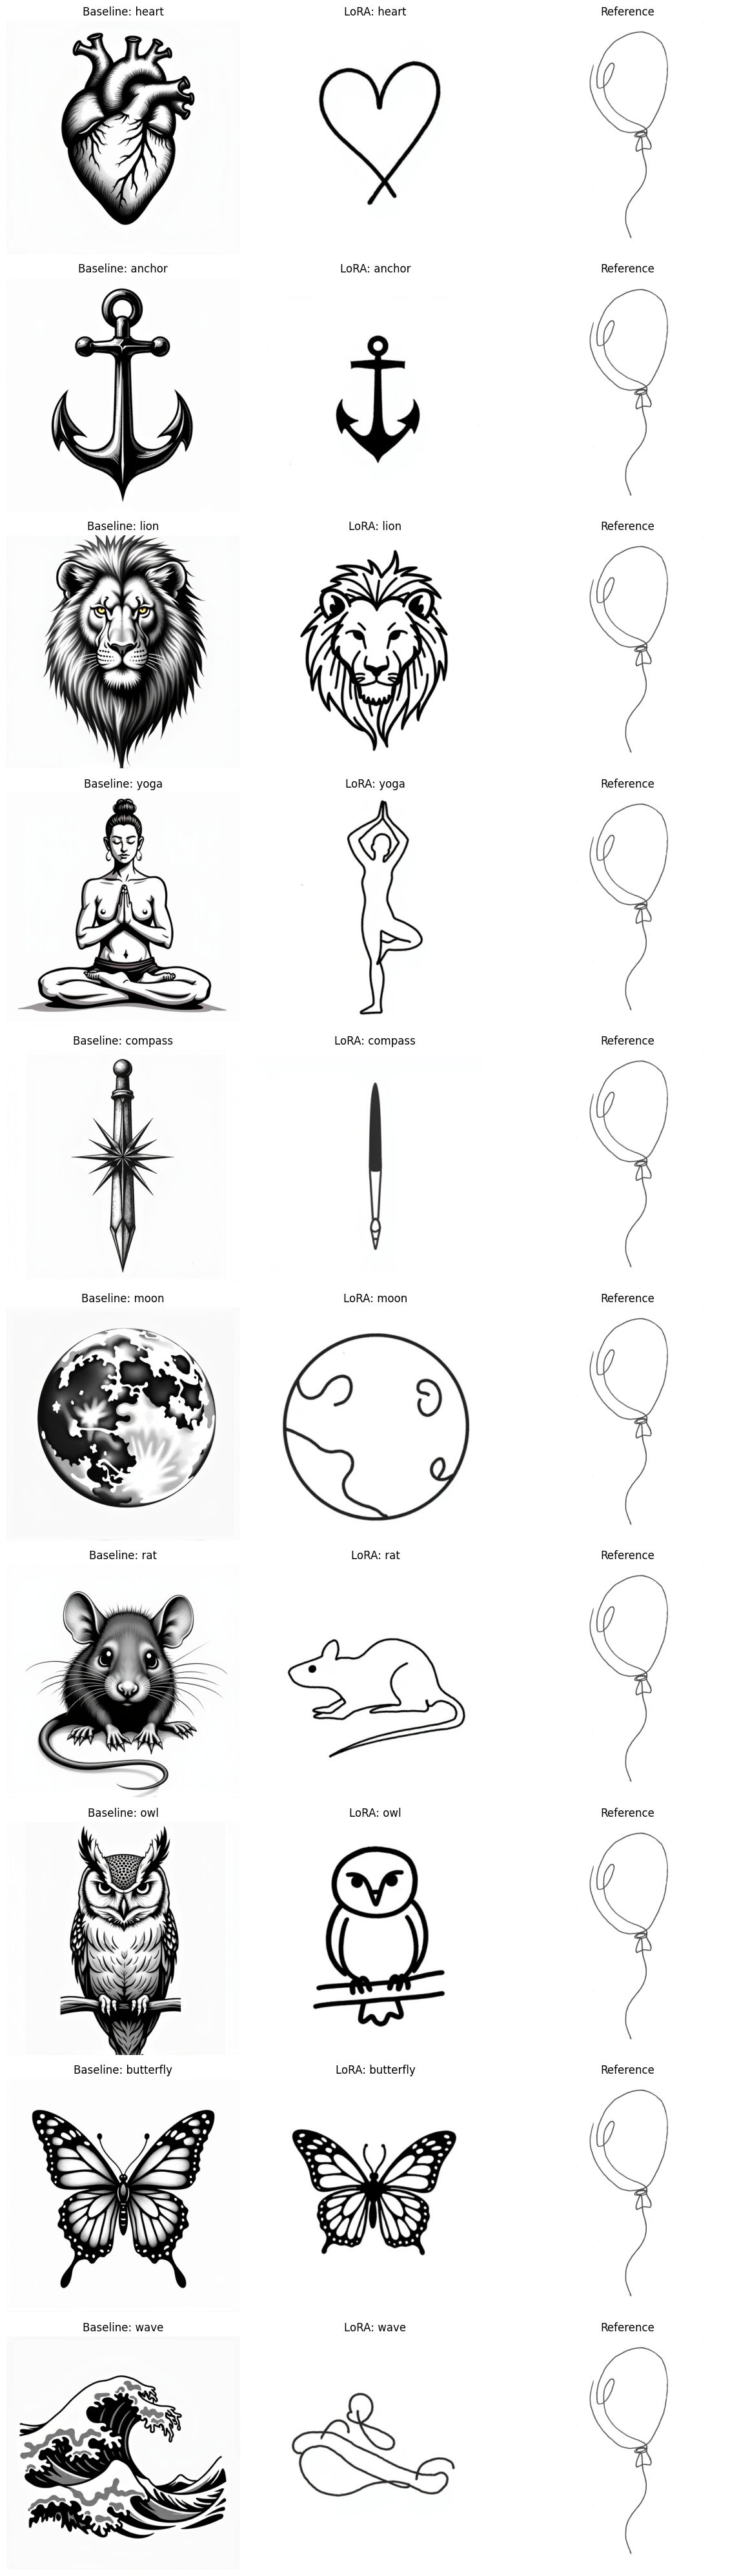

In [19]:
fig, ax_img = plt.subplots(len(prompts), 3, figsize=(12, 4 * len(prompts)))

for i, p in enumerate(prompts):
    img_b = Image.open(f"generated/baseline/baseline_{i}.png")
    img_l = Image.open(f"generated/lora/lora_{i}.png")
    img_r = Image.open(REF_IMAGE_PATH)

    ax_img[i, 0].imshow(img_b)
    ax_img[i, 0].set_title(f"Baseline: {p}")
    ax_img[i, 0].axis("off")

    ax_img[i, 1].imshow(img_l)
    ax_img[i, 1].set_title(f"LoRA: {p}")
    ax_img[i, 1].axis("off")

    ax_img[i, 2].imshow(img_r)
    ax_img[i, 2].set_title("Reference")
    ax_img[i, 2].axis("off")

plt.tight_layout()
plt.show()

## 7. Метрики качества:

Для количественной оценки ключевых особенностей стиля выполнения эскиза тату "одной линии" выбраны следующие метрики:


1. **Skeleton‑based** метрики:

   – components: число непрерывных частей линии - отдельных "кусочков" скелета изображения, не связанных между собой (components==1 означает, что весь скелет представляет собой единую связную структуру без разрывов). Для стиля "одной линии" должно быть components==1;

   – endpoints: количество концевых точек - пиксели с ровно 1 соседом (конец линии). Для стиля "одной линии" должно быть endpoints==2 (начало и конец);

   – branches: точки ветвления - пиксели с >=3 соседями (места, где линии раздваиваются). Для стиля "одной линии" значение зависит от количества пересечений линии, но как правило не должно превышать 10;

   – length: общая длина скелета (в пикселях);

   – tortuosity: отношение длины к прямому расстоянию между концами (если endpoints==2).

2. **Style Loss**:

   – инициализирует VGG-19 с предобученными весами и берёт только сверточные фичи;
   
   – преобразует изображение и эталон в формат, ожидаемый моделью (Resize, ToTensor, Normalize);
   
   – считает Gram-матрицы признаков VGG и возвращает среднеквадратичную разницу между ними, показывая, насколько глубинные паттерны линий сгенерированного изображения отличаются от эталона.

3. **Human Style Score (HSS)**:

   – запрашивает у пользователя субъективную оценку (1–5) для каждого изображения, чтобы учесть человеческое восприятие «правильности» стиля "одной линии".


### 7.1. Оценка Skeleton‑based метрик

#### 7.1.1. Расчет Skeleton‑based метрик для выбранного из датасета референса - получение таким образом «нормы» стиля выполнения тату "одной линии"

In [20]:
def preprocess(img, thr=200):
    """
    1. Конвертирует RGB в BGR, если нужно (для PIL Images)
    2. Конвертирует BGR-изображение в серое.
    3. Бинаризует (линия → белый фон → чёрное).
    4. Выполняет морфологическое closing, чтобы убрать мелкие разрывы.
    5. Возвращает двоичную маску (0/1) для последующего скелетирования.
    """

    if isinstance(img, np.ndarray) and img.shape[2] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, bw = cv2.threshold(g, thr, 255, cv2.THRESH_BINARY_INV)
    bw = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, np.ones((3,3), np.uint8), iterations=2)

    return (bw > 0).astype(np.uint8)

def largest_skeleton(mask, min_size=50):
    """
    1. Строит скелет (однопиксельную «ось») из двоичной маски.
    2. Помечает связанные компоненты на скелете.
    3. Оставляет только те компоненты, чьи размеры ≥ min_size (фильтрация артефактов).
    """

    skel = skeletonize(mask.astype(bool))
    lbl = label(skel, connectivity=2)

    # Фильтрация компонентов
    component_sizes = np.bincount(lbl.ravel())
    small_components = np.where(component_sizes < min_size)[0]
    mask = np.isin(lbl, small_components, invert=True)

    return (skel * mask).astype(np.uint8)

def neighbours(skel):
    """
    Считает для каждого пикселя скелета число соседей в 8-окрестности.
    Это нужно для детекции концов (1 сосед) и развилок (≥3 соседей).
    """

    return cv2.filter2D(skel, -1, np.array([[1,1,1],[1,0,1],[1,1,1]], np.uint8))

def sk_metrics(img):
    """
    1. Препроцессинг и постобработка скелета (largest_skeleton).
    2. Определяет:
       - components  (число связанных компонент)
       - endpoints   (пиксели с 1 соседом)
       - branches    (пиксели с ≥3 соседями)
       - length      (общая длина скелета, в пикселях)
       - tortuosity  (отношение длины скелета к прямому расстоянию между концами, если концов ровно 2)
    3. Возвращает все метрики в виде словаря.
    """

    skel = largest_skeleton(preprocess(img))
    if skel.sum() == 0:
        return dict(components=0, endpoints=0, branches=0, length=0, tortuosity=math.nan)
    neigh = neighbours(skel)
    comps = label(skel, connectivity=2).max()
    ep    = int(np.logical_and(skel==1, neigh==1).sum())
    bp    = int(np.logical_and(skel==1, neigh>=3).sum())
    lng   = int(skel.sum())
    tort  = math.nan
    if ep == 2:
        pts = np.column_stack(np.where(np.logical_and(skel==1, neigh==1)))
        if euclidean(pts[0], pts[1]) > 1e-6:  # Защита от деления на ноль
            tort = lng / euclidean(pts[0], pts[1])
    return dict(components=comps,endpoints=ep,branches=bp,length=lng,tortuosity=tort)

imgs_ref = {"Reference": REF_IMAGE_PATH}

# Расчет нормы метрик и вывод результатов в таблицу
data = {name: sk_metrics(cv2.imread(path)) for name, path in imgs_ref.items()}
ref_df   = pd.DataFrame(data).T
display(ref_df)


,components,endpoints,branches,length,tortuosity
Reference,1.0,2.0,20.0,1153.0,2.973418


#### 7.1.2. Визуализация скелетов по каждому промпту

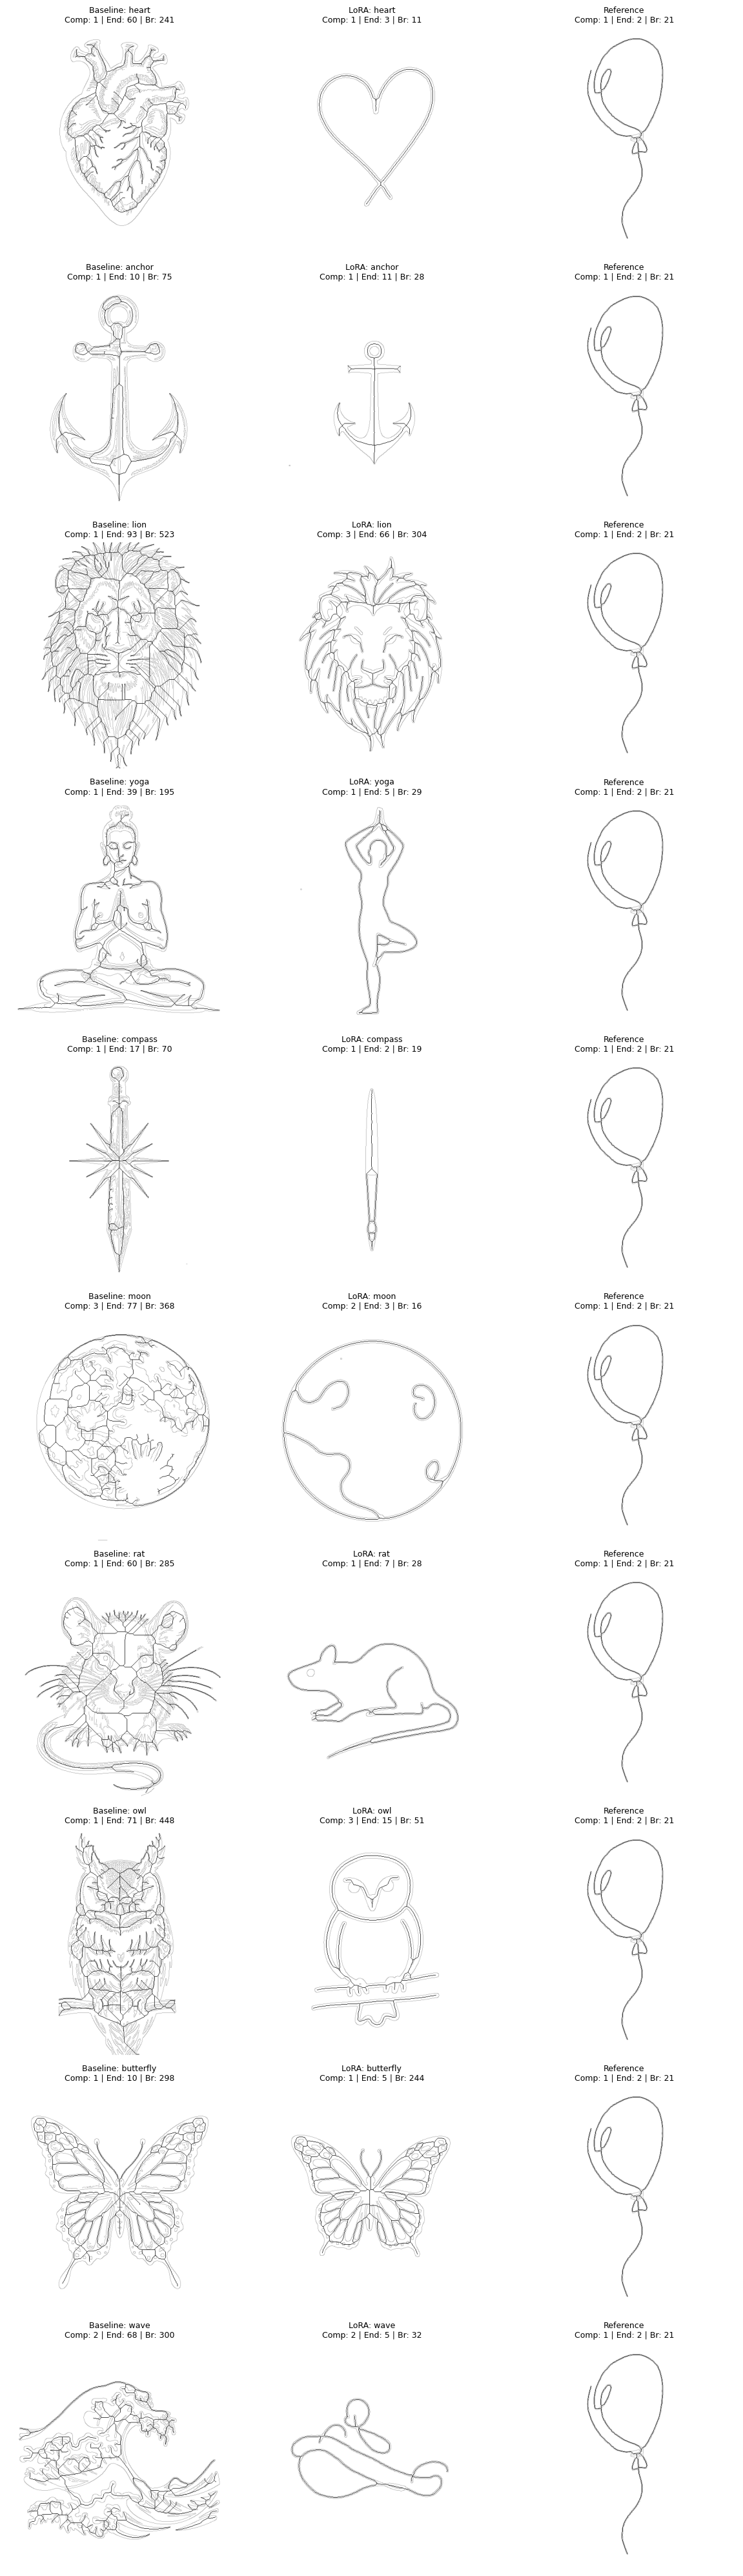

In [21]:
def get_skeleton_for_visualization(pil_img):
    """Отдельная функция для визуализации, идентичная расчету метрик"""
    img_np = np.array(pil_img.convert('RGB'))[:, :, ::-1]  # RGB->BGR
    mask = preprocess(img_np)
    skel = largest_skeleton(mask)

    # Для визуализации добавляем контуры оригинального изображения
    contours = cv2.Canny(cv2.cvtColor(img_np, cv2.COLOR_BGR2GRAY), 100, 200)
    return (skel * 255 + contours * 0.3).clip(0, 255).astype(np.uint8)

fig, axs = plt.subplots(len(prompts), 3, figsize=(12, 4 * len(prompts)))

for i, p in enumerate(prompts):
    # Загрузка и обработка
    img_b = Image.open(f"generated/baseline/baseline_{i}.png")
    img_l = Image.open(f"generated/lora/lora_{i}.png")
    img_r = Image.open(REF_IMAGE_PATH)

    # Получаем скелеты и метрики
    skel_b = get_skeleton_for_visualization(img_b)
    skel_l = get_skeleton_for_visualization(img_l)
    skel_r = get_skeleton_for_visualization(img_r)

    metrics_b = sk_metrics(np.array(img_b)[:, :, ::-1])
    metrics_l = sk_metrics(np.array(img_l)[:, :, ::-1])

    # Визуализация с аннотациями метрик
    def plot_skel(ax, skel, title, metrics):
        ax.imshow(skel, cmap='gray_r', vmin=0, vmax=255)
        ax.set_title(f"{title}\n"
                    f"Comp: {metrics['components']} | "
                    f"End: {metrics['endpoints']} | "
                    f"Br: {metrics['branches']}", fontsize=9)
        ax.axis("off")

    plot_skel(axs[i, 0], skel_b, f"Baseline: {p}", metrics_b)
    plot_skel(axs[i, 1], skel_l, f"LoRA: {p}", metrics_l)
    plot_skel(axs[i, 2], skel_r, "Reference", sk_metrics(np.array(img_r)[:, :, ::-1]))

plt.tight_layout()
plt.show()


#### 7.1.3. Расчет Skeleton‑based метрик для baseline-решения по каждому промпту

In [22]:
# Получаем пути и сортируем ЧИСЛА в названиях файлов (не лексикографически)
baseline_paths = sorted(
    glob.glob("generated/baseline/baseline_*.png"),
    key=lambda x: int(re.search(r'baseline_(\d+)\.png', x).group(1))
)

# Создаем словарь {номер: prompt} для гарантированного соответствия
prompt_dict = {i: prompt for i, prompt in enumerate(prompts)}

records = []
for path in baseline_paths:
    # Извлекаем номер из имени файла
    file_num = int(re.search(r'baseline_(\d+)\.png', path).group(1))

    # Берем соответствующий промпт
    if file_num in prompt_dict:
        img = cv2.imread(path)
        if img is not None:
            metrics = sk_metrics(img)
            metrics["prompt"] = prompt_dict[file_num]
            records.append(metrics)
        else:
            print(f"Ошибка загрузки: {path}")
    else:
        print(f"Нет промпта для файла {path}")

# Создаем DataFrame
baseline_df = pd.DataFrame(records).set_index("prompt")
baseline_df.index.name = None

# Стилизация
styled = (
    baseline_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th.col_heading', 'props': [('text-align', 'left')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ])
)

display(styled)


,components,endpoints,branches,length,tortuosity
heart,1,60,241,3120,nan
anchor,1,10,75,1903,nan
lion,1,93,523,6823,nan
yoga,1,39,195,3628,nan
compass,1,17,70,1627,nan
moon,3,77,368,4683,nan
rat,1,60,285,4664,nan
owl,1,71,448,4607,nan
butterfly,1,10,298,4112,nan
wave,2,68,300,4378,nan


#### 7.1.4. Расчет Skeleton‑based метрик для LoRA по каждому промпту

In [23]:
# Получаем пути и сортируем ЧИСЛА в названиях файлов (не лексикографически)
baseline_paths = sorted(
    glob.glob("generated/lora/lora_*.png"),
    key=lambda x: int(re.search(r'lora_(\d+)\.png', x).group(1))
)

# Создаем словарь {номер: prompt} для гарантированного соответствия
prompt_dict = {i: prompt for i, prompt in enumerate(prompts)}

records = []
for path in baseline_paths:
    # Извлекаем номер из имени файла
    file_num = int(re.search(r'lora_(\d+)\.png', path).group(1))

    # Берем соответствующий промпт
    if file_num in prompt_dict:
        img = cv2.imread(path)
        if img is not None:
            metrics = sk_metrics(img)
            metrics["prompt"] = prompt_dict[file_num]
            records.append(metrics)
        else:
            print(f"Ошибка загрузки: {path}")
    else:
        print(f"Нет промпта для файла {path}")

# Создаем DataFrame
lora_df = pd.DataFrame(records).set_index("prompt")
lora_df.index.name = None

# Стилизация
styled = (
    lora_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th.col_heading', 'props': [('text-align', 'left')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ])
)

display(styled)


,components,endpoints,branches,length,tortuosity
heart,1,3,11,831,nan
anchor,1,11,28,822,nan
lion,3,66,304,4332,nan
yoga,1,5,29,1498,nan
compass,1,2,19,549,1.524994
moon,2,3,16,1962,nan
rat,1,7,28,1750,nan
owl,3,15,51,2014,nan
butterfly,1,5,244,3230,nan
wave,2,5,32,1483,nan


#### 7.1.5. Сравнение средних значений Skeleton‑based метрик baseline и LoRA с референсным значением

Сравнение средних значений skeleton-based метрик:


,components,endpoints,branches,length,tortuosity
Baseline,1.3,50.5,280.3,3954.5,NaN
LoRA,1.6,12.2,76.2,1847.1,1.524994
Reference,1.0,2.0,20.0,1153.0,2.973418


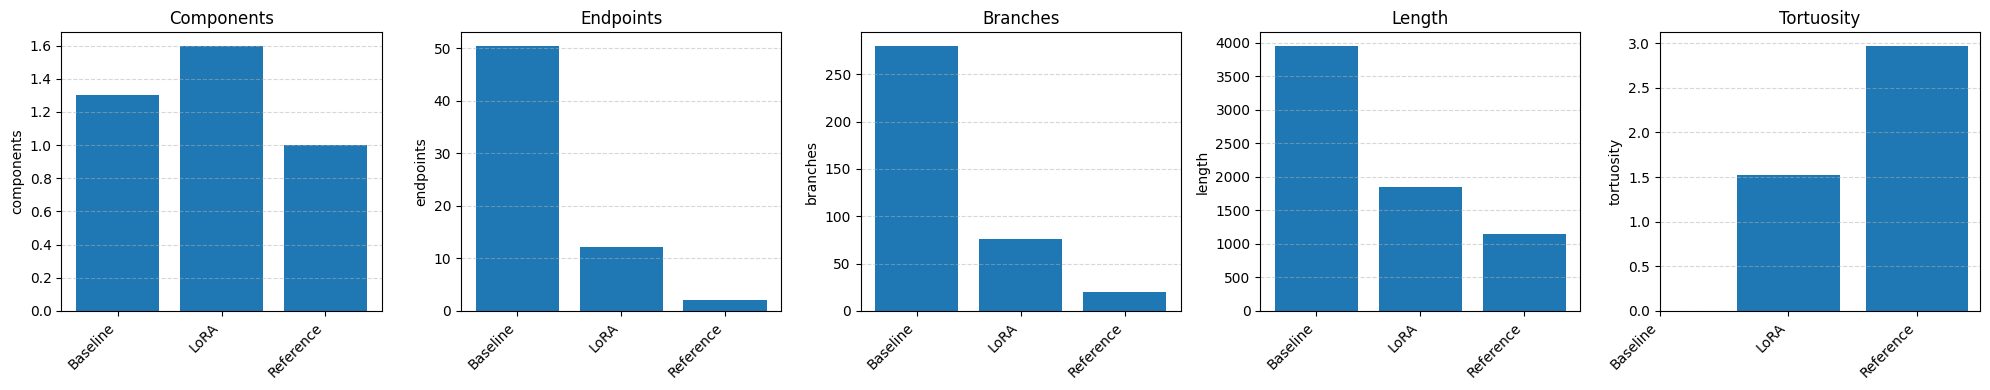

In [40]:
ref_mean = ref_df.mean(numeric_only=True) if len(ref_df)>1 else ref_df.iloc[0]

# Расчет средних значений
baseline_mean = baseline_df.mean(numeric_only=True)
lora_mean     = lora_df.mean(numeric_only=True)

# Формирование итоговой таблицы
summary_skeleton = pd.DataFrame({
    "Baseline":  baseline_mean,
    "LoRA":      lora_mean,
    "Reference": ref_mean
}).T

# Вывод таблицы
print("Сравнение средних значений skeleton-based метрик:")
display(summary_skeleton)

# Визуализация сравнения средних метрик
metrics = summary_skeleton.columns.tolist()
fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), sharey=False)

for ax, m in zip(axes, metrics):
    ax.bar(summary_skeleton.index, summary_skeleton[m])
    ax.set_title(m.capitalize())
    ax.set_ylabel(m)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_xticks(range(len(summary_skeleton.index)))
    ax.set_xticklabels(summary_skeleton.index, rotation=45, ha="right")

plt.tight_layout()
plt.show()


#### 7.1.6. Оценка результатов:

- **components**:

  Baseline и LoRA иногда разделяют рисунок на 2-3 сегмента (разрывы ≤ 1 px). Возможная причина - микропросветы 1–2 px или случайные «вторые штрихи». В обучающем наборе скорее всего встречались крошечные разрывы, скан-шум, «двойной» штрих, соответственно, модель решила, что лёгкий разрыв — допустим.

- **endpoints**:

  Baseline изображения - очень детализированы, с элементами заливки, теней, штрихов — отсюда **большое количество endpoints/branches/length**.

  LoRA сократила количество «обрывов» в ~4 раза, однако ещё в 6 раз выше эталона.

- **branches**:

  LoRA снизила ветвистость в ~3-4 раза — наглядный прогресс к минимализму.

- **length**:

  Baseline из-за высокой детализации изображения характеризуется длинной линией скелета.

  У LoRA длина линии соизмерима с эталоном.

- **tortuosity**:

  Эталонные рисунки имеют запутанную траекторию. LoRA пока «чересчур прямолинейна» — визуально выглядит минималистичней, но ей недостает характерных плавных завитков. Датасет содержит мало примеров с изящными петлями. LoRA тренировалась «быстро» (1 000 step), возможно, что не успела уловить тонкие изгибы.


### 7.2. Оценка метрик Style Loss и HSS + визуализация

#### 7.2.1. Расчет Style Loss и Human Style Score (HSS) метрик по каждому промпту

In [25]:
# Инициализируем VGG-19 с актуальными весами и берем только фичи
weights = VGG19_Weights.IMAGENET1K_V1  # или VGG19_Weights.DEFAULT
vgg = models.vgg19(weights=weights).features.eval()
REF_IMAGE = Image.open(REF_IMAGE_PATH).convert("RGB")

# Штатная предобработка для этих весов
preproc = weights.transforms()

def gram_matrix(x: torch.Tensor) -> torch.Tensor:
    b, d, h, w = x.size()
    f = x.view(b * d, h * w)
    return torch.mm(f, f.t()) / (b * d * h * w)

def style_loss(generated: Image.Image, reference: Image.Image) -> float:

    target_size = (512, 512)  # Фиксированный размер для стабильности

    gen = preproc(generated).unsqueeze(0)  # [1, 3, H, W]
    ref = preproc(reference).unsqueeze(0)
    with torch.no_grad():
        f_gen = vgg(gen)
        f_ref = vgg(ref)
        return torch.mean((gram_matrix(f_gen) - gram_matrix(f_ref)) ** 2).item()

# Счетчики
metrics = {"Baseline": {"StyleLoss": [], "HSS": []},
           "LoRA":     {"StyleLoss": [], "HSS": []}}

# Собираем StyleLoss
for i, prompt in enumerate(prompts):
    img_b = Image.open(f"generated/baseline/baseline_{i}.png").convert("RGB")
    img_l = Image.open(f"generated/lora/lora_{i}.png").convert("RGB")
    metrics["Baseline"]["StyleLoss"].append(style_loss(img_b, REF_IMAGE))
    metrics["LoRA"]["StyleLoss"].append(style_loss(img_l, REF_IMAGE))

# Запрашиваем HSS у пользователя
print("Введите HSS (1–5) для каждого изображения:")
for model in ["Baseline","LoRA"]:
    for i, p in enumerate(prompts):
        val = float(input(f"{model} — {p}: "))
        metrics[model]["HSS"].append(val)

# Формируем DataFrame с индексом — промпты, и столбцами для каждой метрики и модели
df_metrics = pd.DataFrame({
    "Baseline StyleLoss": metrics["Baseline"]["StyleLoss"],
    "LoRA StyleLoss":     metrics["LoRA"]["StyleLoss"],
    "Baseline HSS":       metrics["Baseline"]["HSS"],
    "LoRA HSS":           metrics["LoRA"]["HSS"],
}, index=prompts)

df_metrics.index.name = None

# Стилизация
df_metrics["Baseline StyleLoss"] = df_metrics["Baseline StyleLoss"] / 1e-6
df_metrics["LoRA StyleLoss"]     = df_metrics["LoRA StyleLoss"]     / 1e-6

styled = (
    df_metrics.style
        .format({
            "Baseline StyleLoss": "{:.2f}",
            "LoRA StyleLoss":     "{:.2f}",
            "Baseline HSS":       "{:.1f}",
            "LoRA HSS":           "{:.1f}"
        })
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading', 'props': [('text-align', 'left')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
        ])
)
print("Style Loss (1e-6) и Human Style Score (HSS) метрики по каждому промпту:")
display(styled)


Введите HSS (1–5) для каждого изображения:
Baseline — heart: 1
Baseline — anchor: 1
Baseline — lion: 1
Baseline — yoga: 1
Baseline — compass: 1
Baseline — moon: 1
Baseline — rat: 1
Baseline — owl: 1
Baseline — butterfly: 1
Baseline — wave: 1
LoRA — heart: 2
LoRA — anchor: 2
LoRA — lion: 2
LoRA — yoga: 2
LoRA — compass: 2
LoRA — moon: 2
LoRA — rat: 2
LoRA — owl: 2
LoRA — butterfly: 2
LoRA — wave: 2
Style Loss (1e-6) и Human Style Score (HSS) метрики по каждому промпту:


,Baseline StyleLoss,LoRA StyleLoss,Baseline HSS,LoRA HSS
heart,5.32,0.22,1.0,2.0
anchor,1.07,0.23,1.0,2.0
lion,2.81,0.11,1.0,2.0
yoga,0.36,0.14,1.0,2.0
compass,0.68,0.52,1.0,2.0
moon,4.60,0.11,1.0,2.0
rat,2.94,0.12,1.0,2.0
owl,1.17,0.18,1.0,2.0
butterfly,5.01,0.66,1.0,2.0
wave,0.12,0.03,1.0,2.0


#### 7.2.2. Визуализация Style Loss и Human Style Score (HSS) метрик по каждому промпту

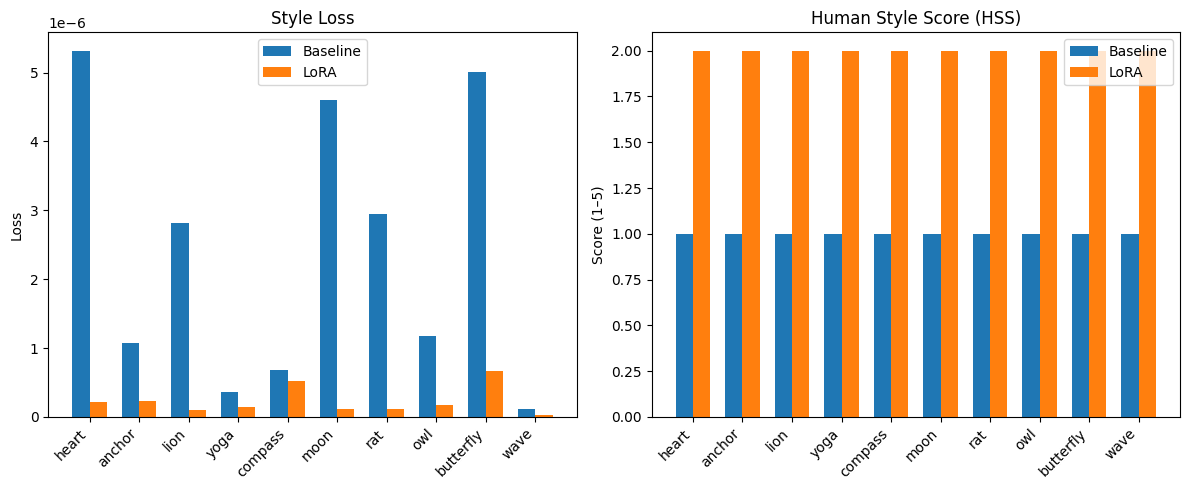

In [26]:
# Визуализация: два bar-чарта в ряд
x    = np.arange(len(prompts))
w    = 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Style Loss
axes[0].bar(x - w/2, metrics["Baseline"]["StyleLoss"], w, label="Baseline")
axes[0].bar(x + w/2, metrics["LoRA"]["StyleLoss"],     w, label="LoRA")
axes[0].set_xticks(x)
axes[0].set_xticklabels(prompts, rotation=45, ha="right")
axes[0].set_title("Style Loss")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Human Style Score
axes[1].bar(x - w/2, metrics["Baseline"]["HSS"], w, label="Baseline")
axes[1].bar(x + w/2, metrics["LoRA"]["HSS"],     w, label="LoRA")
axes[1].set_xticks(x)
axes[1].set_xticklabels(prompts, rotation=45, ha="right")
axes[1].set_title("Human Style Score (HSS)")
axes[1].set_ylabel("Score (1–5)")
axes[1].legend()

plt.tight_layout()
plt.show()


#### 7.2.3. Сравнение средних значений Style Loss и Human Style Score (HSS) метрик baseline и LoRA

,Baseline StyleLoss,LoRA StyleLoss
Mean,2.41,0.23


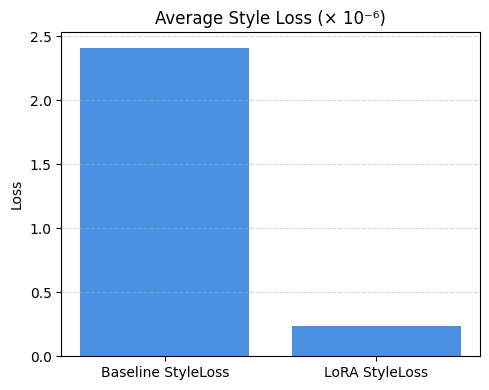

,Baseline HSS,LoRA HSS
Mean,1.0,2.0


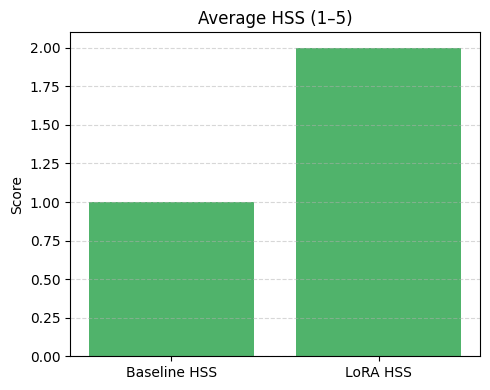

In [27]:
# ===========================================================
# Style Loss (× 10⁻⁶)
# ===========================================================
style_cols = ["Baseline StyleLoss", "LoRA StyleLoss"]

# 1) Среднее
style_mean = df_metrics[style_cols].mean().to_frame(name="Mean").T
style_mean.index.name = None

# 2) Таблица
display(
    style_mean.style
        .format("{:.2f}")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector':'th','props':[('text-align','left')]}])
)

# 3) Диаграмма
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(style_cols, style_mean.loc["Mean"], color="#4A90E2")
ax.set_title("Average Style Loss (× 10⁻⁶)")
ax.set_ylabel("Loss")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# ===========================================================
# Human Style Score (HSS)
# ===========================================================
hss_cols = ["Baseline HSS", "LoRA HSS"]

# 1) Среднее
hss_mean = df_metrics[hss_cols].mean().to_frame(name="Mean").T
hss_mean.index.name = None

# 2) Таблица
display(
    hss_mean.style
        .format("{:.1f}")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector':'th','props':[('text-align','left')]}])
)

# 3) Диаграмма
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(hss_cols, hss_mean.loc["Mean"], color="#50B36B")
ax.set_title("Average HSS (1–5)")
ax.set_ylabel("Score")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


#### 7.2.4. Оценка результатов:

- **Style Loss:**

  LoRA-адаптер уменьшил стилевое расхождение в 10 раз.

  Baseline имеет большие Gram-расхождения.

  Во всех 10 промптах Style Loss для LoRA ≤ 0.66 × 10⁻⁶ (большинство ≈ 0.1-0.2) - стиль ближе к эталону, чем Baseline.

  Самые «трудные» baseline-промпты — heart, butterfly, moon.

  Самые «трудные» LoRA-промпты — compass, butterfly.

- **HSS:**
  
  Субъективно LoRA воспринимается как «узнаваемый стиль», до идеала (4-5) не дотягивает из-за редких разрывов и иногда недостаточной изящности линии.

  Субъективно Baseline - это вообще не стиль тату "одной линии".

## 8. Выводы по решению к заданию 4

### При использовании LoRA-адаптера результаты стали ближе к стилистике техники "одной линии" по сравнению с Baseline-решением, но в сравнении с референсом есть существенные недостатки.

**Причина:**
- fal-ai/flux — это базовый text-to-image движок - он не был специально натренирован на следование правилам "одной линии", и полученные веса LoRA-адаптера не позволяют достигать требуемого результата.

**Предложения по улучшению результата:**
- Увеличить датасет: взять не 51, а, например, 100 референсов, выполненных в стиле тату "одной линии" (без разрывов, шумов, фона, теней, все изображения - одинакового размера черно-белые). Дополнительные референсы должны быть с хорошо замкнутой петлёй и выразительными изгибами (модель будет видеть, что разрыв — ошибка, а плавные петли — норма).

- Тренировать больше шагов: 5000 шагов дадут лучшее закрепление.

- При инференсе немного повысить пораметр LoRA-scale - это усилит влияние адаптера, поможет «заклеить» микропрорывы.

- Попробовать реализовать тонкую post-обработка сгенерированных изображений.

## РЕШЕНИЕ к ЗАДАНИЮ 5 - Улучшаем модель

Для улучшения LoRA-адаптера в целях воспроизведения техники выполнения эскизов тату "одной линии" выбраны:

**Данные**
1. Увеличение датасета через аугментацию - горизонтальное отражение изображения (платформа Fal.ai допускает количество изображений в датасете не более 100, поэтому других вариантов аугментации не предполагается).
**Обучение**
2. Повышение количества шагов обучения LoRA (flux-lora-fast-training) на увеличенном датасете до 5000 с использованием платформы Fal.ai.
3. Использование автоматической генерации масок `create_masks: True` (для обучения стилю "одной линии" маски помогут выделить только контуры, что, возможно, улучшит результат).
**Инференс**
4. Повышение параметра `scale` для усиления влияния LoRA-адаптера.
5. Оптимизация параметров `num_inference_steps`, `guidance_scale`, `main_prompt`.

## 1. Импорт дополнительных библиотек

In [28]:
from PIL import Image, ImageEnhance, ImageDraw
from google.colab.patches import cv2_imshow

## 2. Создание аугментированных данных

In [ ]:
# Создаем папку для аугментированных данных
os.makedirs('/content/augmented_dataset', exist_ok=True)

In [ ]:
def augment_image(img_path, output_dir):
    # Базовое имя файла
    base_name = os.path.splitext(os.path.basename(img_path))[0]

    # Загрузка изображения
    img = Image.open(img_path)

    # Горизонтальное отражение
    img_flip = img.transpose(Image.FLIP_LEFT_RIGHT)
    img_flip.save(f"{output_dir}/{base_name}_flip.png")

# Обработка всех изображений
for img_file in os.listdir('/content/dataset/refs'):
    if img_file.endswith(('.jpg', '.png', '.jpeg')):
        augment_image(f"/content/dataset/refs/{img_file}", "/content/augmented_dataset")

In [ ]:
# Создаем папку для архивирования
os.makedirs('/content/updated_dataset', exist_ok=True)

In [ ]:
# Копируем оригинальные изображения
!cp -r /content/dataset/refs/* /content/updated_dataset/

In [ ]:
# Добавляем аугментированные изображения
!cp /content/augmented_dataset/* /content/updated_dataset/

In [ ]:
# Создаем архив для загрузки на Fal.ai
!zip -r /content/updated_dataset.zip /content/updated_dataset

  adding: content/updated_dataset/ (stored 0%)
  adding: content/updated_dataset/10.png (deflated 7%)
  adding: content/updated_dataset/5_flip.png (deflated 11%)
  adding: content/updated_dataset/22_flip.png (deflated 11%)
  adding: content/updated_dataset/9_flip.png (deflated 15%)
  adding: content/updated_dataset/3_flip.png (deflated 11%)
  adding: content/updated_dataset/48.png (deflated 4%)
  adding: content/updated_dataset/17.png (deflated 13%)
  adding: content/updated_dataset/11.png (deflated 8%)
  adding: content/updated_dataset/8.png (deflated 6%)
  adding: content/updated_dataset/23_flip.png (deflated 12%)
  adding: content/updated_dataset/23.png (deflated 8%)
  adding: content/updated_dataset/14.png (deflated 6%)
  adding: content/updated_dataset/36_flip.png (deflated 9%)
  adding: content/updated_dataset/5.png (deflated 8%)
  adding: content/updated_dataset/28.png (deflated 7%)
  adding: content/updated_dataset/50.png (deflated 9%)
  adding: content/updated_dataset/41.png (

## 3. Загрузка обновленного датасета на платформу Fal.ai

In [ ]:
data_zip_url = fal_client.upload_file("updated_dataset.zip")
print("ZIP загружен:", data_zip_url)

ZIP загружен: https://v3.fal.media/files/elephant/C3V5bDUbyUhhBJNw6boBV_updated_dataset.zip


## 4. Обучение LoRA-адаптера на платформе Fal.ai

Ключевые изменения:
  - `"steps": 5000`
  - `"trigger_word": "single continuous black line with smooth and graceful curves without breaks"`
  - `"create_masks": True`

In [ ]:
handler = fal_client.submit(
    "fal-ai/flux-lora-fast-training",
    arguments={
        "images_data_url": data_zip_url,
        "is_style": True,
        "steps": 5000,
        "trigger_word": "single continuous black line with smooth and graceful curves without breaks",
        "create_masks": True
    }
)

while True:
    status = fal_client.status(
        "fal-ai/flux-lora-fast-training",
        handler.request_id,
        with_logs=True
    )

    if isinstance(status, Queued):
        print(f"В очереди (position={status.position})")

    elif isinstance(status, InProgress):
        for log in status.logs or []:
            print(log.get("message", "<no message>"))

    elif isinstance(status, Completed):
        print("Обучение завершено!")
        break

    else:
        raise RuntimeError(f"Unexpected status object: {status!r}")

    time.sleep(30)

result = fal_client.result("fal-ai/flux-lora-fast-training", handler.request_id)
lora_url = result["diffusers_lora_file"]["url"]
print("LoRA weights:", lora_url)


В очереди (position=0)
Temporary directory: /tmp/tmp6g602veo
Unpacking archive /tmp/tmpo0_5m1b6 to /tmp/tmp6g602veo
Archive files: [PosixPath('/tmp/tmp6g602veo/content')]
file /tmp/tmp6g602veo/content
iterating over /tmp/tmp6g602veo/content
Moving /tmp/tmp6g602veo/content/updated_dataset/31_flip.png to /tmp/tmpb7dtc5lo/flux_general/6c30f057f9225ec6/train/31_flip.png
Image /tmp/tmp6g602veo/content/updated_dataset/31_flip.png has width 512 and height 512
Saving at /tmp/tmpb7dtc5lo/flux_general/6c30f057f9225ec6/train/31_flip.jpg
Moving /tmp/tmp6g602veo/content/updated_dataset/2.png to /tmp/tmpb7dtc5lo/flux_general/6c30f057f9225ec6/train/2.png
Image /tmp/tmp6g602veo/content/updated_dataset/2.png has width 512 and height 512
Saving at /tmp/tmpb7dtc5lo/flux_general/6c30f057f9225ec6/train/2.jpg
Moving /tmp/tmp6g602veo/content/updated_dataset/5.png to /tmp/tmpb7dtc5lo/flux_general/6c30f057f9225ec6/train/5.png
Image /tmp/tmp6g602veo/content/updated_dataset/5.png has width 512 and height 512
Sav

Файл весов обученного LoRA-адаптера (`"steps": 3000`):

In [ ]:
lora_url = "https://v3.fal.media/files/penguin/O1_RKyPsRx0phG9Dpy65P_pytorch_lora_weights.safetensors"

In [ ]:
TRIG  = "<single continuous black line drawing, minimalism, no shading, no breaks>"

Файл весов обученного LoRA-адаптера (`"steps": 5000`):

In [29]:
lora_url = "https://v3.fal.media/files/koala/IVHmdaYvIIp3lU2b34HA6_pytorch_lora_weights.safetensors"

In [30]:
TRIG  = "<single continuous black line with smooth and graceful curves without breaks>"

## 5. Генерация изображений

Ключевые изменения:
- `TRIG  = "<single continuous black line with smooth and graceful curves without breaks>"`
- `"scale": 1.2`
- актуализирован промпт и негативный промпт, оптимизированы параметры генерации

In [31]:
MODEL = "fal-ai/flux-lora"
LORA  = lora_url

def generate(prompt, use_lora=False):
    seed = random.randint(1, 1_000_000_000)

    # Формируем основной текст промпта
    main_prompt = (
        f"{prompt}"
        #"clean and sharp outlines optimized for tattoo sketch, "
        #"strong contrast and clear readability. "
    )

    args = {
        # Добавляем в prompt триггер
        "prompt": f"{TRIG} depicting {main_prompt}" if use_lora else main_prompt,
        "negative_prompt": (
            "filling, painting, pencil shading, grayscale shading, "
            "color gradients, blurred edges, gray background, colour background"
        ),
        "image_size": { "width": 512, "height": 512 },
        "num_inference_steps": 28,
        "guidance_scale": 4.8,
        "seed": seed
    }

    if use_lora:
        args["loras"] = [{ "path": LORA, "scale": 1.2 }]

    result = fal_client.run(MODEL, arguments=args)
    url = result["images"][0]["url"]
    return Image.open(requests.get(url, stream=True).raw).convert("RGB")


# Директория для сохранения
os.makedirs("generated/lora_imp",     exist_ok=True)

# Список популярных тату
object_list = [
    "skull", "rose", "anchor", "rat", "cat", "wolf", "moon", "gun",
    "lion", "feather", "sun", "heart", "fish", "bird", "mountain", "tree",
    "diamond", "yoga", "clock", "flower", "dreamcatcher", "butterfly",
    "compass", "wave", "owl", "snake", "dragon", "crown", "arrow", "star"
]

prompts = random.sample(object_list, 10)

for i, p in enumerate(prompts):
    img_lora = generate(p, use_lora=True)
    img_lora.save(f"generated/lora_imp/lora_imp_{i}.png")


## 6. Визуализация сгенерированных результатов и референса

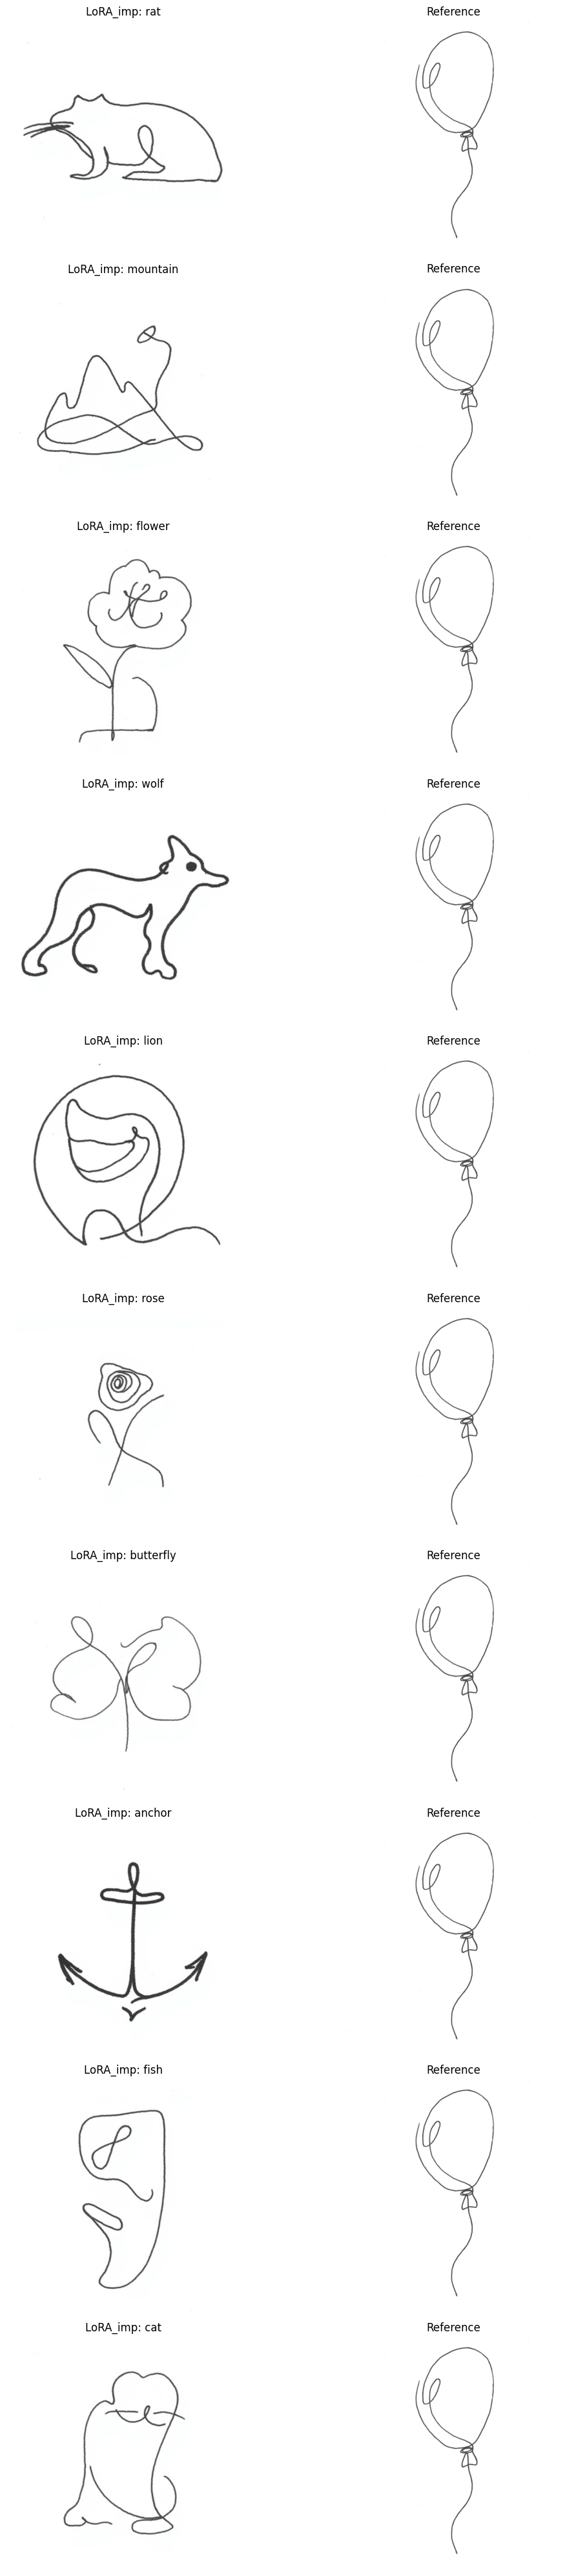

In [32]:
fig, ax_img = plt.subplots(len(prompts), 2, figsize=(12, 4 * len(prompts)))

for i, p in enumerate(prompts):
    img_l = Image.open(f"generated/lora_imp/lora_imp_{i}.png")
    img_r = Image.open(REF_IMAGE_PATH)

    ax_img[i, 0].imshow(img_l)
    ax_img[i, 0].set_title(f"LoRA_imp: {p}")
    ax_img[i, 0].axis("off")

    ax_img[i, 1].imshow(img_r)
    ax_img[i, 1].set_title("Reference")
    ax_img[i, 1].axis("off")

plt.tight_layout()
plt.show()


## 7. Метрики качества

### 7.1 Оценка Skeleton-based метрик

#### 7.1.1. Визуализация скелетов по каждому промпту

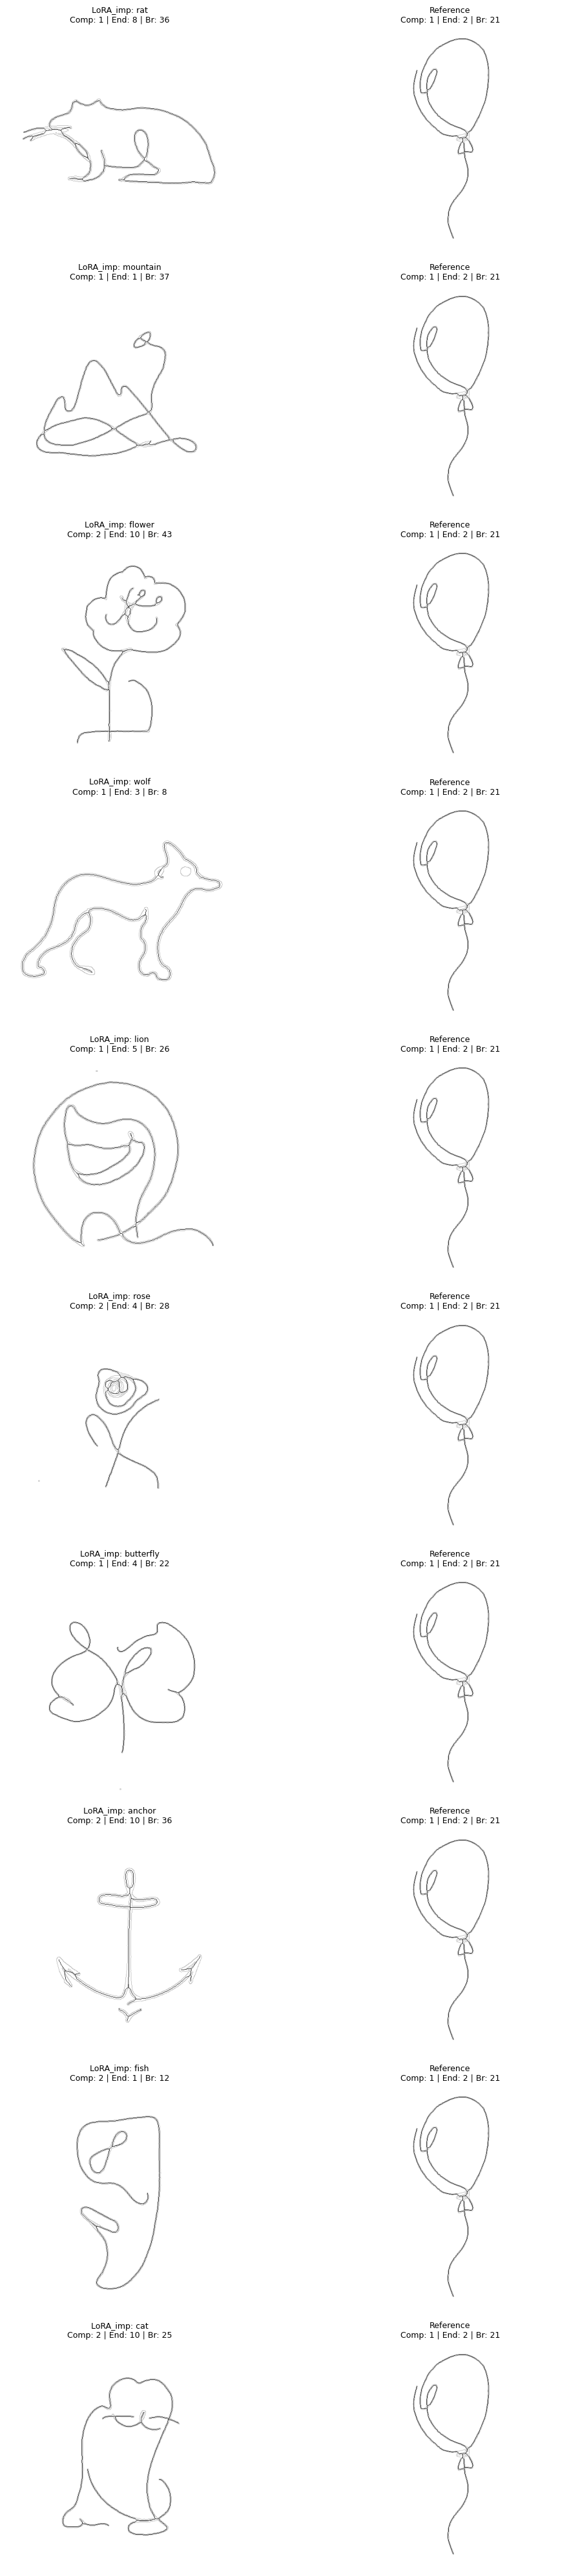

In [33]:
def get_skeleton_for_visualization_imp(pil_img):
    """Функция для визуализации, идентичная расчету метрик"""
    img_np = np.array(pil_img.convert('RGB'))[:, :, ::-1]  # RGB->BGR
    mask = preprocess(img_np)
    skel = largest_skeleton(mask)

    # Для визуализации добавляем контуры оригинального изображения
    contours = cv2.Canny(cv2.cvtColor(img_np, cv2.COLOR_BGR2GRAY), 100, 200)
    return (skel * 255 + contours * 0.3).clip(0, 255).astype(np.uint8)

fig, axs = plt.subplots(len(prompts), 2, figsize=(12, 4 * len(prompts)))

for i, p in enumerate(prompts):
    # Загрузка и обработка
    img_l = Image.open(f"generated/lora_imp/lora_imp_{i}.png")
    img_r = Image.open(REF_IMAGE_PATH)

    # Получаем скелеты и метрики
    skel_l = get_skeleton_for_visualization_imp(img_l)
    skel_r = get_skeleton_for_visualization_imp(img_r)

    metrics_l = sk_metrics(np.array(img_l)[:, :, ::-1])

    # Визуализация с аннотациями метрик
    def plot_skel(ax, skel, title, metrics):
        ax.imshow(skel, cmap='gray_r', vmin=0, vmax=255)
        ax.set_title(f"{title}\n"
                    f"Comp: {metrics['components']} | "
                    f"End: {metrics['endpoints']} | "
                    f"Br: {metrics['branches']}", fontsize=9)
        ax.axis("off")

    plot_skel(axs[i, 0], skel_l, f"LoRA_imp: {p}", metrics_l)
    plot_skel(axs[i, 1], skel_r, "Reference", sk_metrics(np.array(img_r)[:, :, ::-1]))

plt.tight_layout()
plt.show()


#### 7.1.2. Расчет Skeleton‑based метрик для улучшенного LoRA по каждому промпту

In [34]:
# Получаем пути и сортируем ЧИСЛА в названиях файлов (не лексикографически)
baseline_paths = sorted(
    glob.glob("generated/lora_imp/lora_imp_*.png"),
    key=lambda x: int(re.search(r'lora_imp_(\d+)\.png', x).group(1))
)

# Создаем словарь {номер: prompt} для гарантированного соответствия
prompt_dict = {i: prompt for i, prompt in enumerate(prompts)}

records = []
for path in baseline_paths:
    # Извлекаем номер из имени файла
    file_num = int(re.search(r'lora_imp_(\d+)\.png', path).group(1))

    # Берем соответствующий промпт
    if file_num in prompt_dict:
        img = cv2.imread(path)
        if img is not None:
            metrics = sk_metrics(img)
            metrics["prompt"] = prompt_dict[file_num]
            records.append(metrics)
        else:
            print(f"Ошибка загрузки: {path}")
    else:
        print(f"Нет промпта для файла {path}")

# Создаем DataFrame
lora_df_imp = pd.DataFrame(records).set_index("prompt")
lora_df_imp.index.name = None

# Стилизация
styled = (
    lora_df_imp.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th.col_heading', 'props': [('text-align', 'left')]},
        {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
    ])
)

display(styled)


,components,endpoints,branches,length,tortuosity
rat,1,8,36,1500,nan
mountain,1,1,37,1689,nan
flower,2,10,43,1777,nan
wolf,1,3,8,1639,nan
lion,1,5,26,2383,nan
rose,2,4,28,1100,nan
butterfly,1,4,22,1493,nan
anchor,2,10,36,1130,nan
fish,2,1,12,1430,nan
cat,2,10,25,1579,nan


#### 7.1.3. Сравнение средних значений Skeleton‑based метрик LoRA и улучшенного LoRA с референсным значением

Сравнение средних значений skeleton-based метрик:


,components,endpoints,branches,length,tortuosity
LoRA,1.6,12.2,76.2,1847.1,1.524994
LoRA_imp,1.5,5.6,27.3,1572.0,NaN
Reference,1.0,2.0,20.0,1153.0,2.973418


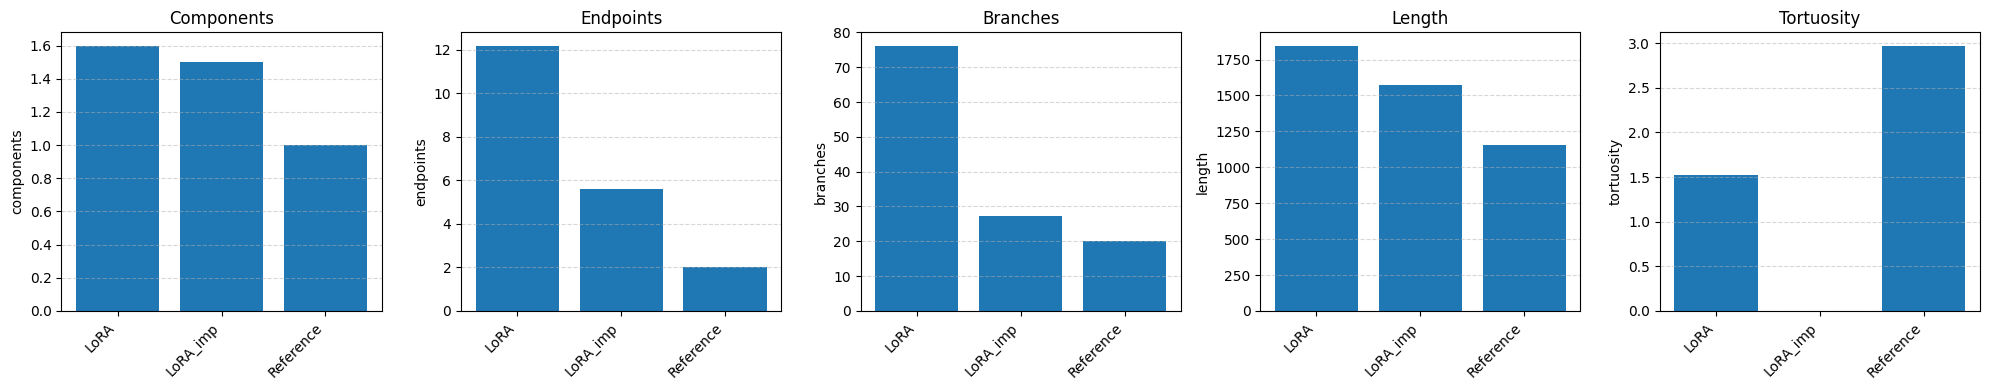

In [39]:
ref_mean = ref_df.mean(numeric_only=True) if len(ref_df)>1 else ref_df.iloc[0]

# Расчет средних значений
lora_imp_mean = lora_df_imp.mean(numeric_only=True)

# Формирование итоговой таблицы
summary_skeleton = pd.DataFrame({
    "LoRA":      lora_mean,
    "LoRA_imp":  lora_imp_mean,
    "Reference": ref_mean
}).T

# Вывод таблицы
print("Сравнение средних значений skeleton-based метрик:")
display(summary_skeleton)

# Визуализация сравнения средних метрик
metrics = summary_skeleton.columns.tolist()
fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), sharey=False)

for ax, m in zip(axes, metrics):
    ax.bar(summary_skeleton.index, summary_skeleton[m])
    ax.set_title(m.capitalize())
    ax.set_ylabel(m)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_xticks(range(len(summary_skeleton.index)))
    ax.set_xticklabels(summary_skeleton.index, rotation=45, ha="right")

plt.tight_layout()
plt.show()


#### 7.1.4. Оценка результатов:

- **components**:

  Метрика немного лучше, чем у LoRA, но всё ещё > 1 (в ~50 % генераций остаётся деление изображения).

- **endpoints**:

  Количество концевых точек сократилось в 2 раза; до нормы остается ≈ 3–4 лишних «хвоста».

- **branches**:

  Ветвистость снизилась на 64 % и почти достигла референсного значения.

- **length**:

  Линия укорочена ещё на 15 % и на 400 px ближе к референсу.

- **tortuosity**:

  У LoRA была «чересчур прямая» линия; у улучшенного LoRA часть рисунков всё-ещё имеет > 2 концов, поэтому показатель не рассчитывается.


### 7.2. Оценка метрик Style Loss и HSS + визуализация

#### 7.2.1. Расчет Style Loss и Human Style Score (HSS) метрик по каждому промпту для улучшенного LoRA

In [36]:
def gram_matrix_imp(x: torch.Tensor) -> torch.Tensor:
    b, d, h, w = x.size()
    f = x.view(b * d, h * w)
    return torch.mm(f, f.t()) / (b * d * h * w)

def style_loss_imp(generated: Image.Image, reference: Image.Image) -> float:

    target_size = (512, 512)  # Фиксированный размер для стабильности

    gen = preproc(generated).unsqueeze(0)  # [1, 3, H, W]
    ref = preproc(reference).unsqueeze(0)
    with torch.no_grad():
        f_gen = vgg(gen)
        f_ref = vgg(ref)
        return torch.mean((gram_matrix_imp(f_gen) - gram_matrix_imp(f_ref)) ** 2).item()

# Счетчики
metrics_imp = {"LoRA_imp":     {"StyleLoss": [], "HSS": []}}

# Собираем StyleLoss
for i, prompt in enumerate(prompts):
    img_i = Image.open(f"generated/lora_imp/lora_imp_{i}.png").convert("RGB")
    metrics_imp["LoRA_imp"]["StyleLoss"].append(style_loss_imp(img_i, REF_IMAGE))

# Запрашиваем HSS у пользователя
print("Введите HSS (1–5) для каждого изображения:")
for model in ["LoRA_imp"]:
    for i, p in enumerate(prompts):
        val = float(input(f"{model} — {p}: "))
        metrics_imp[model]["HSS"].append(val)

# Формируем DataFrame с индексом — промпты, и столбцами для каждой метрики и модели
df_metrics_imp = pd.DataFrame({
    "LoRA_imp StyleLoss": metrics_imp["LoRA_imp"]["StyleLoss"],
    "LoRA_imp HSS":       metrics_imp["LoRA_imp"]["HSS"],
}, index=prompts)

df_metrics_imp.index.name = None

# Стилизация
df_metrics_imp["LoRA_imp StyleLoss"] = df_metrics_imp["LoRA_imp StyleLoss"] / 1e-6

styled = (
    df_metrics_imp.style
        .format({
            "LoRA_imp StyleLoss": "{:.2f}",
            "LoRA_imp HSS":       "{:.1f}"
        })
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([
            {'selector': 'th.col_heading', 'props': [('text-align', 'left')]},
            {'selector': 'th.row_heading', 'props': [('text-align', 'left')]},
        ])
)
print("Style Loss (1e-6) и Human Style Score (HSS) метрики по каждому промпту:")
display(styled)


Введите HSS (1–5) для каждого изображения:
LoRA_imp — rat: 4
LoRA_imp — mountain: 4
LoRA_imp — flower: 3
LoRA_imp — wolf: 3
LoRA_imp — lion: 2
LoRA_imp — rose: 3
LoRA_imp — butterfly: 4
LoRA_imp — anchor: 3
LoRA_imp — fish: 2
LoRA_imp — cat: 4
Style Loss (1e-6) и Human Style Score (HSS) метрики по каждому промпту:


,LoRA_imp StyleLoss,LoRA_imp HSS
rat,0.04,4.0
mountain,0.06,4.0
flower,0.06,3.0
wolf,0.12,3.0
lion,0.05,2.0
rose,0.06,3.0
butterfly,0.03,4.0
anchor,0.11,3.0
fish,0.05,2.0
cat,0.03,4.0


#### 7.2.2. Визуализация Style Loss и Human Style Score (HSS) метрик по каждому промпту

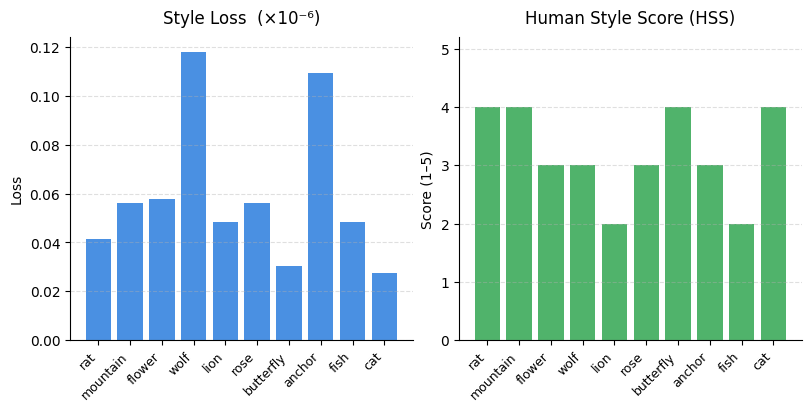

In [37]:
style_imp = df_metrics_imp["LoRA_imp StyleLoss"].values
hss_imp   = df_metrics_imp["LoRA_imp HSS"].values

x = np.arange(len(prompts))

fig, axes = plt.subplots(
    1, 2,
    figsize=(max(8, 0.6*len(prompts)), 4),
    constrained_layout=True
)

# ---------- Style Loss ----------
axes[0].bar(x, style_imp, color="#4A90E2")
axes[0].set_title("Style Loss  (×10⁻⁶)", pad=10)
axes[0].set_ylabel("Loss")
axes[0].set_xticks(x)
axes[0].set_xticklabels(prompts, rotation=45, ha="right", fontsize=9)
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].spines[["top", "right"]].set_visible(False)

# ---------- HSS ----------
axes[1].bar(x, hss_imp, color="#50B36B")
axes[1].set_title("Human Style Score (HSS)", pad=10)
axes[1].set_ylabel("Score (1–5)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(prompts, rotation=45, ha="right", fontsize=9)
axes[1].set_ylim(0, 5.2)
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
axes[1].spines[["top", "right"]].set_visible(False)

plt.show()


#### 7.2.3. Сравнение средних значений Style Loss и Human Style Score (HSS) метрик LoRA и улучшенного LoRA

,LoRA StyleLoss,LoRA_imp StyleLoss
Mean,0.23,0.06


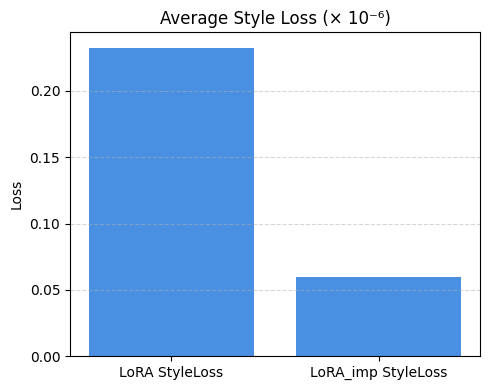

,LoRA HSS,LoRA_imp HSS
Mean,2.0,3.2


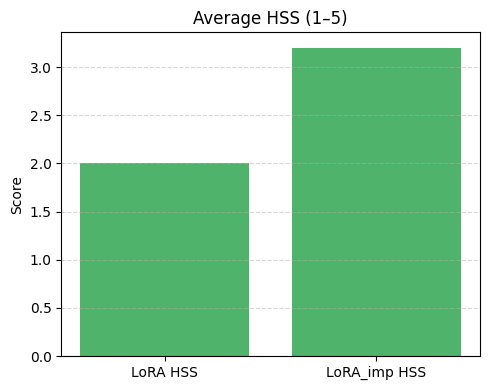

In [38]:
# -----------------------------
# 1. Style Loss (× 10⁻⁶)
# -----------------------------
style_mean = pd.DataFrame({
    "LoRA StyleLoss":     [df_metrics["LoRA StyleLoss"].mean()],
    "LoRA_imp StyleLoss": [df_metrics_imp["LoRA_imp StyleLoss"].mean()]
})
style_mean.index = ["Mean"]          # одна строка «Mean»

# Таблица
display(
    style_mean.style
        .format("{:.2f}")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector':'th','props':[('text-align','left')]}])
)

# Диаграмма
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(style_mean.columns, style_mean.loc["Mean"], color="#4A90E2")
ax.set_title("Average Style Loss (× 10⁻⁶)")
ax.set_ylabel("Loss")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Human Style Score (HSS)
# -----------------------------
hss_mean = pd.DataFrame({
    "LoRA HSS":     [df_metrics["LoRA HSS"].mean()],
    "LoRA_imp HSS": [df_metrics_imp["LoRA_imp HSS"].mean()]
})
hss_mean.index = ["Mean"]

# Таблица
display(
    hss_mean.style
        .format("{:.1f}")
        .set_properties(**{'text-align': 'left'})
        .set_table_styles([{'selector':'th','props':[('text-align','left')]}])
)

# Диаграмма
fig, ax = plt.subplots(figsize=(5,4))
ax.bar(hss_mean.columns, hss_mean.loc["Mean"], color="#50B36B")
ax.set_title("Average HSS (1–5)")
ax.set_ylabel("Score")
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


#### 7.2.4. Оценка результатов:

- **Style Loss:**

  Улучшенный LoRA-адаптер уменьшил стилевое расхождение почти в 4 раза.

  Самые «трудные» LoRA-промпты — wolf, anchor.

- **HSS:**
  
  Субъективно улучшенный LoRA воспринимается как «стиль одной линии», до идеала (5) не дотягивает из-за разрывов изображения.


## 8. Выводы по решению к заданию 5

#### При улучшении LoRA-адаптера результаты визуально и согласно метрикам значительно улучшились и стали схожи со стилистикой техники "одной линии".

#### Улучшенный LoRA сделал явный шаг к эталону: улучшил все skeleton-based метрики и сократил стилевое расхождение.

#### Новый LoRA-адаптер решает ключевую проблему «лишней сложности линии», осталось добиться стабильной непрерывности линии и чуть повысить изящность изгибов — после этого метрики будут почти не отличимы от референса.

#### Предлагается включить данный стиль в качестве нового стиля сервиса генерации уникальных эскизов тату (MVP) - https://t.me/TattiSketchBot